# Benchmark Analysis: CVDV vs Bosonic-Qiskit vs qcvdv

Load saved JSON results and generate comparison plots with log scale.

## 1. Import Required Libraries

In [1]:
import json
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Notebook display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 13
# Zero padding for LaTeX inclusion — bbox_inches='tight' handles cropping.
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0


## 2. Load Result Files

In [2]:
# Set up paths
current_dir = Path('.')
legacy_results_dir = current_dir / 'results'
campaign_root = legacy_results_dir / 'perlmutter_runs'
images_dir = current_dir / 'images'
images_dir.mkdir(parents=True, exist_ok=True)

# Discover per-run outputs written by run.sh sbatch campaigns.
result_files = sorted(campaign_root.glob('*/runs/*/benchmark_results.txt'))
legacy_file = legacy_results_dir / 'benchmark_results.txt'
if not result_files and legacy_file.exists():
    result_files = [legacy_file]

all_results = []
for result_file in result_files:
    try:
        with open(result_file, 'r') as f:
            payload = json.load(f)
        payload['_source_file'] = str(result_file)
        all_results.append(payload)
    except Exception as exc:
        print(f"[WARN] Failed to read {result_file}: {exc}")

if all_results:
    print(f"✓ Loaded {len(all_results)} result file(s)")
    dv_values = sorted({int(r.get('config', {}).get('dv_qubits', -1)) for r in all_results if r.get('config', {}).get('dv_qubits', None) is not None})
    print(f"  DV values present: {dv_values}")
    selected_dv = dv_values[0] if dv_values else None
    print(f"  Selected DV for plotting: {selected_dv}")
    print(f"  First file: {all_results[0].get('_source_file')}")
else:
    selected_dv = None
    print(f"✗ No result files found under {campaign_root}")
    print(f"  Expected pattern: <campaign>/runs/<tag>/benchmark_results.txt")

✓ Loaded 32 result file(s)
  DV values present: [2, 3, 4, 5, 6]
  Selected DV for plotting: 2
  First file: results/perlmutter_runs/20260521_132415_jobs8_runs10_warmup2/runs/dv2__cv4/benchmark_results.txt


## 3. Parse and Structure Data

In [3]:
# Extract and organize benchmark data from all loaded runs.
if not all_results:
    raise RuntimeError('No benchmark result files available. Run run.sh first.')

# Optional DV filter. Set to an int (e.g., 4) to view one DV only; keep None to plot all DVs.
selected_dv = None

from collections import defaultdict

pair_results = []
for results in all_results:
    dv_q = results.get('config', {}).get('dv_qubits', None)
    if dv_q is None:
        continue
    dv_q = int(dv_q)
    if selected_dv is not None and dv_q != int(selected_dv):
        continue
    pair_results.append((dv_q, results))

if not pair_results:
    raise RuntimeError('No runs available after applying DV filter.')

# Aggregate means keyed by (dv, cv) pairs.
cvdv_acc = defaultdict(list)
bosonic_acc = defaultdict(list)
qcvdv_acc = defaultdict(lambda: defaultdict(list))

# Keep latest detailed payload per (dv, cv) key for component breakdown plotting.
cvdv_data = {}
bosonic_data = {}
qcvdv_data = defaultdict(dict)

for dv_q, results in pair_results:
    current_cvdv_data = results.get('cvdv', {})
    for cv_q_str, data in current_cvdv_data.items():
        cv_q = int(cv_q_str)
        pair = (dv_q, cv_q)
        if data.get('mean_ms') is not None:
            cvdv_acc[pair].append(float(data['mean_ms']))
        cvdv_data[pair] = data

    current_bosonic_data = results.get('bosonic', {})
    for cv_q_str, data in current_bosonic_data.items():
        cv_q = int(cv_q_str)
        pair = (dv_q, cv_q)
        if data.get('mean_ms') is not None:
            bosonic_acc[pair].append(float(data['mean_ms']))
        bosonic_data[pair] = data

    current_qcvdv_data = results.get('qcvdv', {})
    for method, method_data in current_qcvdv_data.items():
        for cv_q_str, data in method_data.items():
            cv_q = int(cv_q_str)
            pair = (dv_q, cv_q)
            if data.get('mean_ms') is not None:
                qcvdv_acc[method][pair].append(float(data['mean_ms']))
            qcvdv_data[method][pair] = data

cvdv_times = {pair: float(np.mean(vals)) for pair, vals in cvdv_acc.items() if vals}
bosonic_times = {pair: float(np.mean(vals)) for pair, vals in bosonic_acc.items() if vals}
qcvdv_times = {
    method: {pair: float(np.mean(vals)) for pair, vals in method_vals.items() if vals}
    for method, method_vals in qcvdv_acc.items()
}

all_pairs = sorted(
    set(cvdv_times.keys())
    | set(bosonic_times.keys())
    | set(pair for method_vals in qcvdv_times.values() for pair in method_vals.keys()),
    key=lambda x: (x[0], x[1])
)

dv_values = sorted({dv for dv, _ in all_pairs})
cv_values = sorted({cv for _, cv in all_pairs})
print(f"DV values in plot: {dv_values}")
print(f"CV sizes in plot: {cv_values}")
print(f"Pairs plotted: {len(all_pairs)}")
print(f"qcvdv methods: {list(qcvdv_times.keys())}")
for method in qcvdv_times:
    method_pairs = sorted(qcvdv_times[method].keys(), key=lambda x: (x[0], x[1]))
    print(f"  {method}: {method_pairs}")

DV values in plot: [2, 3, 4, 5, 6]
CV sizes in plot: [4, 5, 6, 7, 8, 9, 10, 11]
Pairs plotted: 32
qcvdv methods: ['dense_matrix_gpu', 'dense_matrix_gpuv1', 'torch']
  dense_matrix_gpu: [(2, 4), (2, 7), (2, 9), (3, 4), (3, 5), (3, 6), (3, 7), (3, 10), (3, 11), (4, 4), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (4, 10), (4, 11), (5, 4), (5, 6), (5, 7), (5, 8), (5, 9), (5, 10), (5, 11), (6, 4), (6, 5), (6, 6), (6, 7), (6, 8), (6, 9), (6, 10), (6, 11)]
  dense_matrix_gpuv1: [(2, 4), (2, 7), (2, 9), (3, 4), (3, 5), (3, 6), (3, 7), (3, 10), (3, 11), (4, 4), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (4, 10), (4, 11), (5, 4), (5, 6), (5, 7), (5, 8), (5, 9), (5, 10), (5, 11), (6, 4), (6, 5), (6, 6), (6, 7), (6, 8), (6, 9), (6, 10), (6, 11)]
  torch: [(2, 4), (2, 7), (2, 9), (3, 4), (3, 5), (3, 6), (3, 7), (3, 10), (3, 11), (4, 4), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (4, 10), (4, 11), (5, 4), (5, 6), (5, 7), (5, 8), (5, 9), (5, 10), (5, 11), (6, 4), (6, 5), (6, 6), (6, 7), (6, 8), (6, 9), (6, 10)

In [4]:

# ── Patch dense_matrix_gpu profiler data from batch logs ────────────────────
# contextlib.redirect_stdout only captures Python sys.stdout, not C++ std::cout.
# The C++ DenseMatrixSimulatorGPU profiler writes to fd 1 directly, so the
# run_matrix_generation_mean_ms values in benchmark_results.txt are 0.0.
# This cell reads the batch .out logs to extract the real profiler values.

import re as _re
import numpy as _np
from pathlib import Path as _Path
from collections import defaultdict as _defaultdict

_PROFILER_GPU_RE = _re.compile(
    r'\[PROFILER DenseMatrixSimulatorGPU::run\]\s+'
    r'matrix_generation=([0-9.e+\-]+)s,\s*apply=([0-9.e+\-]+)s,\s*'
    r'build=([0-9.e+\-]+)s,\s*transfer=([0-9.e+\-]+)s,\s*'
    r'cache_hit=([0-9.e+\-]+)s,\s*other=([0-9.e+\-]+)s,\s*total=([0-9.e+\-]+)s'
)
_CONFIG_GPU_RE = _re.compile(
    r'\[qcvdv:dense_matrix_gpu\] Configuration: DV=(\d+) qubits, CV=(\d+) qubits'
)


def _parse_batch_log_for_gpu_profiler(log_path, warmup=2):
    """
    Parse a batch .out log file and return dict mapping (dv, cv) -> profiler stats dict.
    The warmup runs are excluded (first `warmup` profiler lines per config block).
    """
    lines = _Path(log_path).read_text(errors='replace').splitlines()

    # Find config markers with their line indices
    config_markers = []  # list of ((dv, cv), line_idx)
    profiler_lines = []  # list of (line_idx, parsed_dict)

    for i, line in enumerate(lines):
        m = _CONFIG_GPU_RE.search(line)
        if m:
            config_markers.append(((int(m.group(1)), int(m.group(2))), i))
        m2 = _PROFILER_GPU_RE.search(line)
        if m2:
            profiler_lines.append((i, {
                'matrix_generation': float(m2.group(1)),
                'apply': float(m2.group(2)),
                'build': float(m2.group(3)),
                'transfer': float(m2.group(4)),
                'cache_hit': float(m2.group(5)),
                'other': float(m2.group(6)),
                'total': float(m2.group(7)),
            }))

    if not config_markers or not profiler_lines:
        return {}

    # Group profiler lines by config block.
    # Each config block gets the profiler lines that appear between its marker
    # and the next config marker (or end of file).
    result = {}
    for ci, (pair, marker_idx) in enumerate(config_markers):
        next_marker_idx = config_markers[ci + 1][1] if ci + 1 < len(config_markers) else len(lines)
        block_lines = [d for idx, d in profiler_lines if marker_idx < idx < next_marker_idx]
        if not block_lines:
            continue
        # Drop warmup runs (first `warmup` entries)
        run_lines = block_lines[warmup:]
        if not run_lines:
            run_lines = block_lines  # fallback: use all if not enough
        keys = ['matrix_generation', 'apply', 'build', 'transfer', 'cache_hit', 'other', 'total']
        stats = {}
        for k in keys:
            vals = [d[k] for d in run_lines]
            stats[k] = {
                'mean': float(_np.mean(vals)),
                'std': float(_np.std(vals)),
                'min': float(_np.min(vals)),
                'max': float(_np.max(vals)),
            }
        result[pair] = stats
    return result


# Discover batch log directories
_batch_log_dirs = sorted(campaign_root.glob('*/batch_logs'))

_gpu_profiler_data = {}  # (dv, cv) -> stats dict (mean over all log files)
_gpu_profiler_accum = _defaultdict(lambda: _defaultdict(list))  # (dv,cv) -> key -> list of means

for _log_dir in _batch_log_dirs:
    for _log_file in sorted(_log_dir.glob('*.out')):
        _parsed = _parse_batch_log_for_gpu_profiler(_log_file, warmup=2)
        for _pair, _stats in _parsed.items():
            for _k, _sv in _stats.items():
                _gpu_profiler_accum[_pair][_k].append(_sv['mean'])

# Average across log files (each file is a different campaign/pair, so usually 1 file)
for _pair, _key_lists in _gpu_profiler_accum.items():
    _gpu_profiler_data[_pair] = {k: float(_np.mean(v)) for k, v in _key_lists.items()}

print(f"Parsed GPU profiler data for {len(_gpu_profiler_data)} (dv, cv) pairs from batch logs")

# Patch qcvdv_data['dense_matrix_gpu'] entries with real profiler values
_patched = 0
for _pair, _prof in _gpu_profiler_data.items():
    if _pair in qcvdv_data.get('dense_matrix_gpu', {}):
        _d = qcvdv_data['dense_matrix_gpu'][_pair]
        _d['run_matrix_generation_mean_ms'] = _prof['matrix_generation'] * 1000
        _d['run_apply_mean_ms'] = _prof['apply'] * 1000
        _d['run_make_circuit_mean_ms'] = _prof['build'] * 1000
        _d['run_transfer_mean_ms'] = _prof['transfer'] * 1000
        _d['run_cache_hit_mean_ms'] = _prof['cache_hit'] * 1000
        _d['run_other_mean_ms'] = _prof['other'] * 1000
        _d['run_total_mean_ms'] = _prof['total'] * 1000
        _patched += 1

print(f"Patched {_patched} dense_matrix_gpu entries with real profiler values")
if _gpu_profiler_data:
    _example_pair = next(iter(_gpu_profiler_data))
    _example = _gpu_profiler_data[_example_pair]
    print(f"Example {_example_pair}: matrix_gen={_example['matrix_generation']*1000:.1f}ms, apply={_example['apply']*1000:.1f}ms")


Parsed GPU profiler data for 31 (dv, cv) pairs from batch logs
Patched 31 dense_matrix_gpu entries with real profiler values
Example (5, 11): matrix_gen=120782.7ms, apply=1100.3ms


## 4. Generate and Save Plots as PDFs

### 4.1 Total Runtime Comparison (Log Scale)

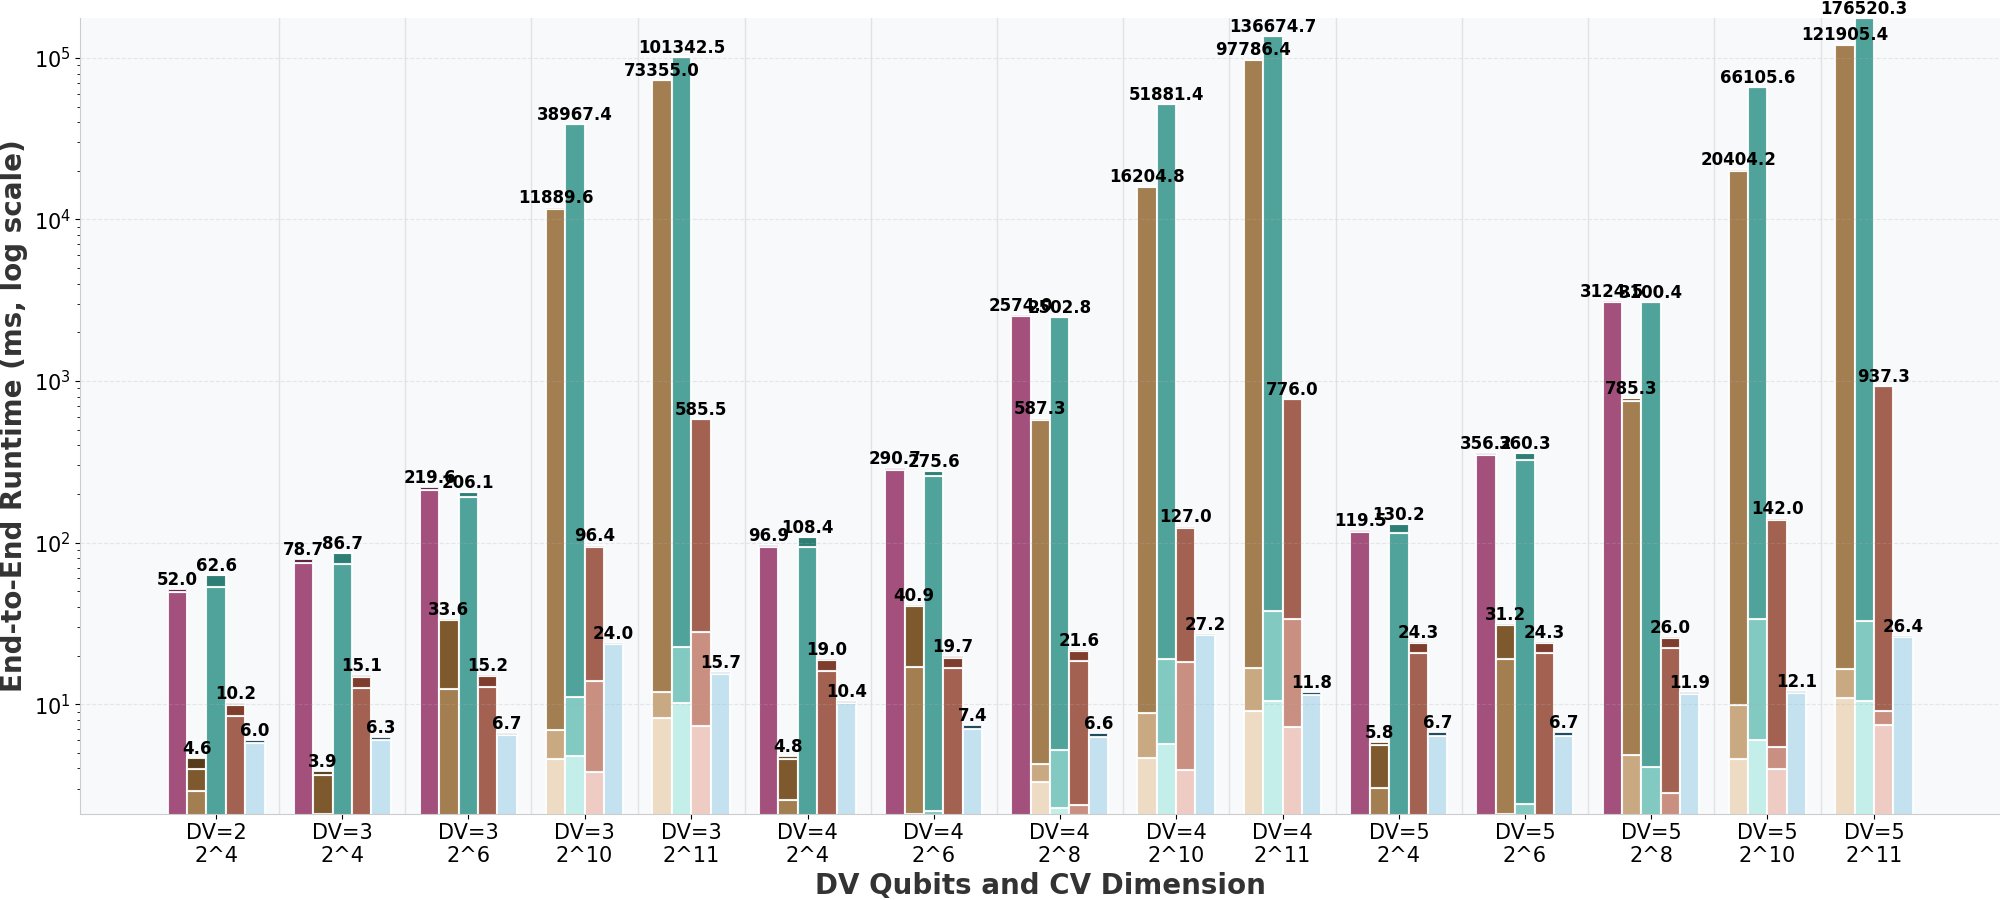

✓ Saved: images/comparison_log_scale.pdf


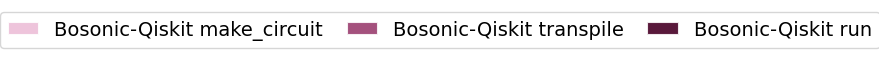

✓ Saved: images/legend_Bosonic-Qiskit.pdf


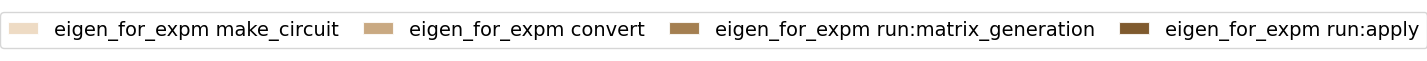

✓ Saved: images/legend_eigen_for_expm.pdf


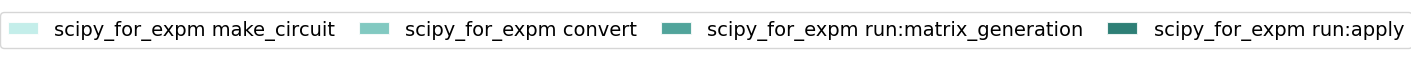

✓ Saved: images/legend_scipy_for_expm.pdf


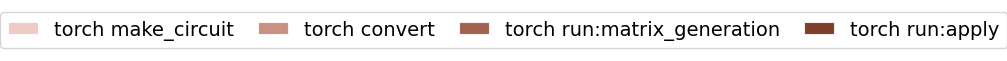

✓ Saved: images/legend_torch.pdf


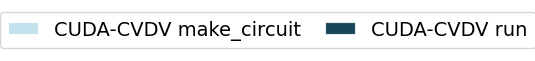

✓ Saved: images/legend_CUDA-CVDV.pdf


In [5]:

import matplotlib.colors as mcolors
import colorsys
from matplotlib.patches import Patch

# ── shade helper ───────────────────────────────────────────────────────────────
def make_shades(base_hex, n, v_light=0.93, v_dark=0.28, s_light=0.20, s_dark=1.0):
    """n shades from lightest (index 0, bottom) to darkest (index n-1, top)."""
    if n == 1:
        return [base_hex]
    h, _, _ = colorsys.rgb_to_hsv(*mcolors.to_rgb(base_hex))
    shades = []
    for i in range(n):
        t = i / (n - 1)
        shades.append(mcolors.to_hex(colorsys.hsv_to_rgb(
            h,
            s_light + t * (s_dark - s_light),
            v_light + t * (v_dark - v_light),
        )))
    return shades

# ── base hues per backend ──────────────────────────────────────────────────────
BOSONIC_BASE       = '#A23B72'
CVDV_BASE          = '#2E86AB'
QCVDV_METHOD_BASES = ['#E07B00', '#1B998B', '#C73E1D', '#6A4C93', '#3A86FF']

# Bosonic: 3 segments (bottom→top): make_circuit, transpile, run
bosonic_shades = make_shades(BOSONIC_BASE, 3)
bosonic_make_circuit_c, bosonic_transpile_c, bosonic_run_c = bosonic_shades

# CUDA-CVDV: 2 segments (bottom→top): make_circuit, run
cvdv_shades = make_shades(CVDV_BASE, 2)
cvdv_make_circuit_c, cvdv_run_c = cvdv_shades

# Named qcvdv run sub-components shown in the legend (bottom→top within the run block).
# All remaining run time is absorbed into an unlabelled 'run:rest' segment (bar only, no legend).
# Data keys: run_matrix_generation_mean_ms, run_apply_mean_ms.
# Verified: apply << matrix_generation (e.g. torch: ~3 ms vs ~36 ms).
RUN_SPLIT_KEYS = ['matrix_generation', 'apply']

# Display name overrides for qcvdv methods (raw method name → label shown in plot/legend).
# Actual keys in benchmark data: dense_matrix_gpu, dense_matrix_gpuv1, torch.
METHOD_DISPLAY_NAMES = {'dense_matrix_gpu': 'eigen_for_expm', 'dense_matrix_gpuv1': 'scipy_for_expm'}

# ── per-method palette, computed once for shade consistency across all pairs ───
def _method_has_run_split(method):
    for pair_data in qcvdv_data.get(method, {}).values():
        if any(float(pair_data.get(f'run_{k}_mean_ms', 0.0)) > 0 for k in RUN_SPLIT_KEYS):
            return True
    return False

# n_segs = make_circuit + convert + named sub-comps + run:rest
method_n_segs = {
    method: (2 + len(RUN_SPLIT_KEYS) + 1) if _method_has_run_split(method) else 3
    for method in sorted(qcvdv_times.keys())
}
method_shades = {
    method: make_shades(QCVDV_METHOD_BASES[idx % len(QCVDV_METHOD_BASES)], method_n_segs[method])
    for idx, method in enumerate(sorted(qcvdv_times.keys()))
}

# ── filter / plot settings ─────────────────────────────────────────────────────
plot_dv_qubits = [2, 3, 4, 5]
plot_cv_qubits = [4, 6, 8, 10, 11]

width = 0.8
fig, ax = plt.subplots(figsize=(20, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8F9FA')

bar_configs      = []
bar_segments     = []
x_positions      = []
group_centers    = []
group_labels     = []
group_boundaries = []
bar_spacing = 0.8
group_gap   = 1.2
current_x   = 0.0

pairs_by_dv = defaultdict(list)
for pair in all_pairs:
    dv, cv = pair
    if dv in plot_dv_qubits and cv in plot_cv_qubits:
        pairs_by_dv[dv].append(pair)

for dv_q in sorted(pairs_by_dv.keys()):
    for _, cv_q in sorted(pairs_by_dv[dv_q], key=lambda x: x[1]):
        pair = (dv_q, cv_q)
        group_positions = []
        group_entries   = []

        # ── Bosonic-Qiskit ────────────────────────────────────────────────────
        bosonic_res = bosonic_data.get(pair)
        if bosonic_res is not None:
            mc_ms = float(bosonic_res.get('make_circuit_mean_ms', 0.0))
            tr_ms = float(bosonic_res.get('transpile_mean_ms', 0.0))
            ru_ms = float(bosonic_res.get('run_mean_ms', bosonic_times.get(pair, 0.0)))
            group_entries.append(('Bosonic-Qiskit', [
                ('Bosonic-Qiskit make_circuit', mc_ms, bosonic_make_circuit_c),
                ('Bosonic-Qiskit transpile',    tr_ms, bosonic_transpile_c),
                ('Bosonic-Qiskit run',          ru_ms, bosonic_run_c),
            ]))

        # ── qcvdv methods ─────────────────────────────────────────────────────
        for method_idx, method in enumerate(sorted(qcvdv_times.keys())):
            if qcvdv_times[method].get(pair) is None:
                continue
            display_name = METHOD_DISPLAY_NAMES.get(method, method)
            res    = qcvdv_data.get(method, {}).get(pair, {})
            mc_ms  = float(res.get('make_circuit_mean_ms', 0.0))
            con_ms = float(res.get('convert_mean_ms', 0.0))
            ru_ms  = float(res.get('run_mean_ms', qcvdv_times[method][pair]))
            shades = method_shades[method]
            n_segs = method_n_segs[method]

            if n_segs > 3:  # run-split case
                named_vals = [float(res.get(f'run_{k}_mean_ms', 0.0)) for k in RUN_SPLIT_KEYS]
                rest_val   = max(0.0, ru_ms - sum(named_vals))
                segs = (
                    [(f'{display_name} make_circuit', mc_ms,  shades[0]),
                     (f'{display_name} convert',       con_ms, shades[1])]
                    + [(f'{display_name} run:{k}', v, shades[2 + i])
                       for i, (k, v) in enumerate(zip(RUN_SPLIT_KEYS, named_vals))]
                    + [(f'{display_name} run:rest', rest_val, shades[2 + len(RUN_SPLIT_KEYS)])]
                )
            else:
                segs = [
                    (f'{display_name} make_circuit', mc_ms,  shades[0]),
                    (f'{display_name} convert',       con_ms, shades[1]),
                    (f'{display_name} run',           ru_ms,  shades[2]),
                ]
            group_entries.append((display_name, segs))

        # ── CUDA-CVDV ─────────────────────────────────────────────────────────
        cvdv_res = cvdv_data.get(pair)
        if cvdv_res is not None:
            mc_ms = float(cvdv_res.get('make_circuit_mean_ms', 0.0))
            ru_ms = float(cvdv_res.get('run_mean_ms', cvdv_times.get(pair, 0.0)))
            group_entries.append(('CUDA-CVDV', [
                ('CUDA-CVDV make_circuit', mc_ms, cvdv_make_circuit_c),
                ('CUDA-CVDV run',          ru_ms, cvdv_run_c),
            ]))

        if not group_entries:
            continue

        for lib, segments in group_entries:
            bar_configs.append((lib, dv_q, cv_q))
            bar_segments.append(segments)
            x_positions.append(current_x)
            group_positions.append(current_x)
            current_x += bar_spacing

        group_centers.append(float(np.mean(group_positions)))
        group_labels.append(f'DV={dv_q}\n2^{cv_q}')
        group_boundaries.append(group_positions[-1] + (bar_spacing + group_gap) / 2)
        current_x += group_gap

# ── draw bars ──────────────────────────────────────────────────────────────────
bars = []
for x_pos, segments in zip(x_positions, bar_segments):
    bottom = total_height = 0.0
    top_bar = None
    for seg_label, seg_val, seg_color in segments:
        top_bar = ax.bar(x_pos, seg_val, width, bottom=bottom,
                         color=seg_color, alpha=0.9, edgecolor='white', linewidth=1.5)[0]
        bottom       += seg_val
        total_height += seg_val
    bars.append((top_bar, total_height))

# Label only bars with non-zero total (y=0 is undefined on log scale)
for bar, total_height in bars:
    if total_height > 0:
        ax.text(bar.get_x() + bar.get_width() / 2., total_height,
                f'{total_height:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# ── build legend structures ────────────────────────────────────────────────────
# 'run:rest' segments appear in bars to keep heights honest, but are excluded from legends.
legend_map = {}
for segments in bar_segments:
    for label, _, color in segments:
        if label not in legend_map and not label.endswith(':rest'):
            legend_map[label] = color

ordered_backends = (
    ['Bosonic-Qiskit']
    + [METHOD_DISPLAY_NAMES.get(m, m) for m in sorted(qcvdv_times.keys())]
    + ['CUDA-CVDV']
)
backend_groups = {b: [] for b in ordered_backends}
for label in legend_map:
    if label.startswith('Bosonic-Qiskit'):
        backend_groups['Bosonic-Qiskit'].append(label)
    elif label.startswith('CUDA-CVDV'):
        backend_groups['CUDA-CVDV'].append(label)
    else:
        bname = label.split(' ', 1)[0]
        if bname in backend_groups:
            backend_groups[bname].append(label)
# Groups are in lightest→darkest order (first-seen = bottom→top insertion order).

# ── axis styling ───────────────────────────────────────────────────────────────
ax.set_ylabel('End-to-End Runtime (ms, log scale)', fontsize=20, fontweight='bold', color='#333')
ax.set_xlabel('DV Qubits and CV Dimension', fontsize=20, fontweight='bold', color='#333')
ax.set_yscale('log')
ax.set_xticks(group_centers)
ax.set_xticklabels(group_labels, fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
for boundary in group_boundaries[:-1]:
    ax.axvline(boundary, color='#DDDDDD', linewidth=1.0, alpha=0.8)
ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout(pad=0)
plt.show()

comparison_pdf = images_dir / 'comparison_log_scale.pdf'
fig.savefig(comparison_pdf, format='pdf', bbox_inches='tight', pad_inches=0, facecolor='white')
print(f"✓ Saved: {comparison_pdf}")
plt.close(fig)

# ── per-backend legend PDFs (one per backend, single horizontal row) ───────────
for backend_name in ordered_backends:
    grp = backend_groups[backend_name]
    if not grp:
        continue
    elems = [
        Patch(facecolor=legend_map[lbl], alpha=0.9, edgecolor='white', linewidth=1.5, label=lbl)
        for lbl in grp  # lightest → darkest (left → right)
    ]
    n_items = len(elems)
    leg_fig, leg_ax = plt.subplots(figsize=(max(4.0, 2.5 * n_items), 0.8))
    leg_ax.axis('off')
    leg = leg_ax.legend(
        handles=elems, loc='center', ncol=n_items,
        fontsize=14, frameon=True, shadow=False, fancybox=True,
        handlelength=1.6, columnspacing=1.2,
    )
    leg.get_frame().set_edgecolor('#CCCCCC')
    leg.get_frame().set_linewidth(1.0)
    safe_name = backend_name.replace(':', '_').replace('/', '_')
    leg_pdf = images_dir / f'legend_{safe_name}.pdf'
    leg_fig.canvas.draw()
    bbox = leg.get_window_extent(leg_fig.canvas.get_renderer()).transformed(leg_fig.dpi_scale_trans.inverted())
    plt.show()
    leg_fig.savefig(leg_pdf, format='pdf', bbox_inches=bbox, pad_inches=0, facecolor='white')
    print(f"✓ Saved: {leg_pdf}")
    plt.close(leg_fig)


### results_w_same_final_circuit analysis

✓ Found 15 files in 20260521_175511_jobs20_runs10_warmup2
  Pairs available: 15  DV=[2, 3, 4, 5, 6, 7, 8]  CV=[10, 11, 12]
  QCVDV methods: ['dense_matrix_gpu']


✓ Saved: images/comparison_same_final_circuit.pdf


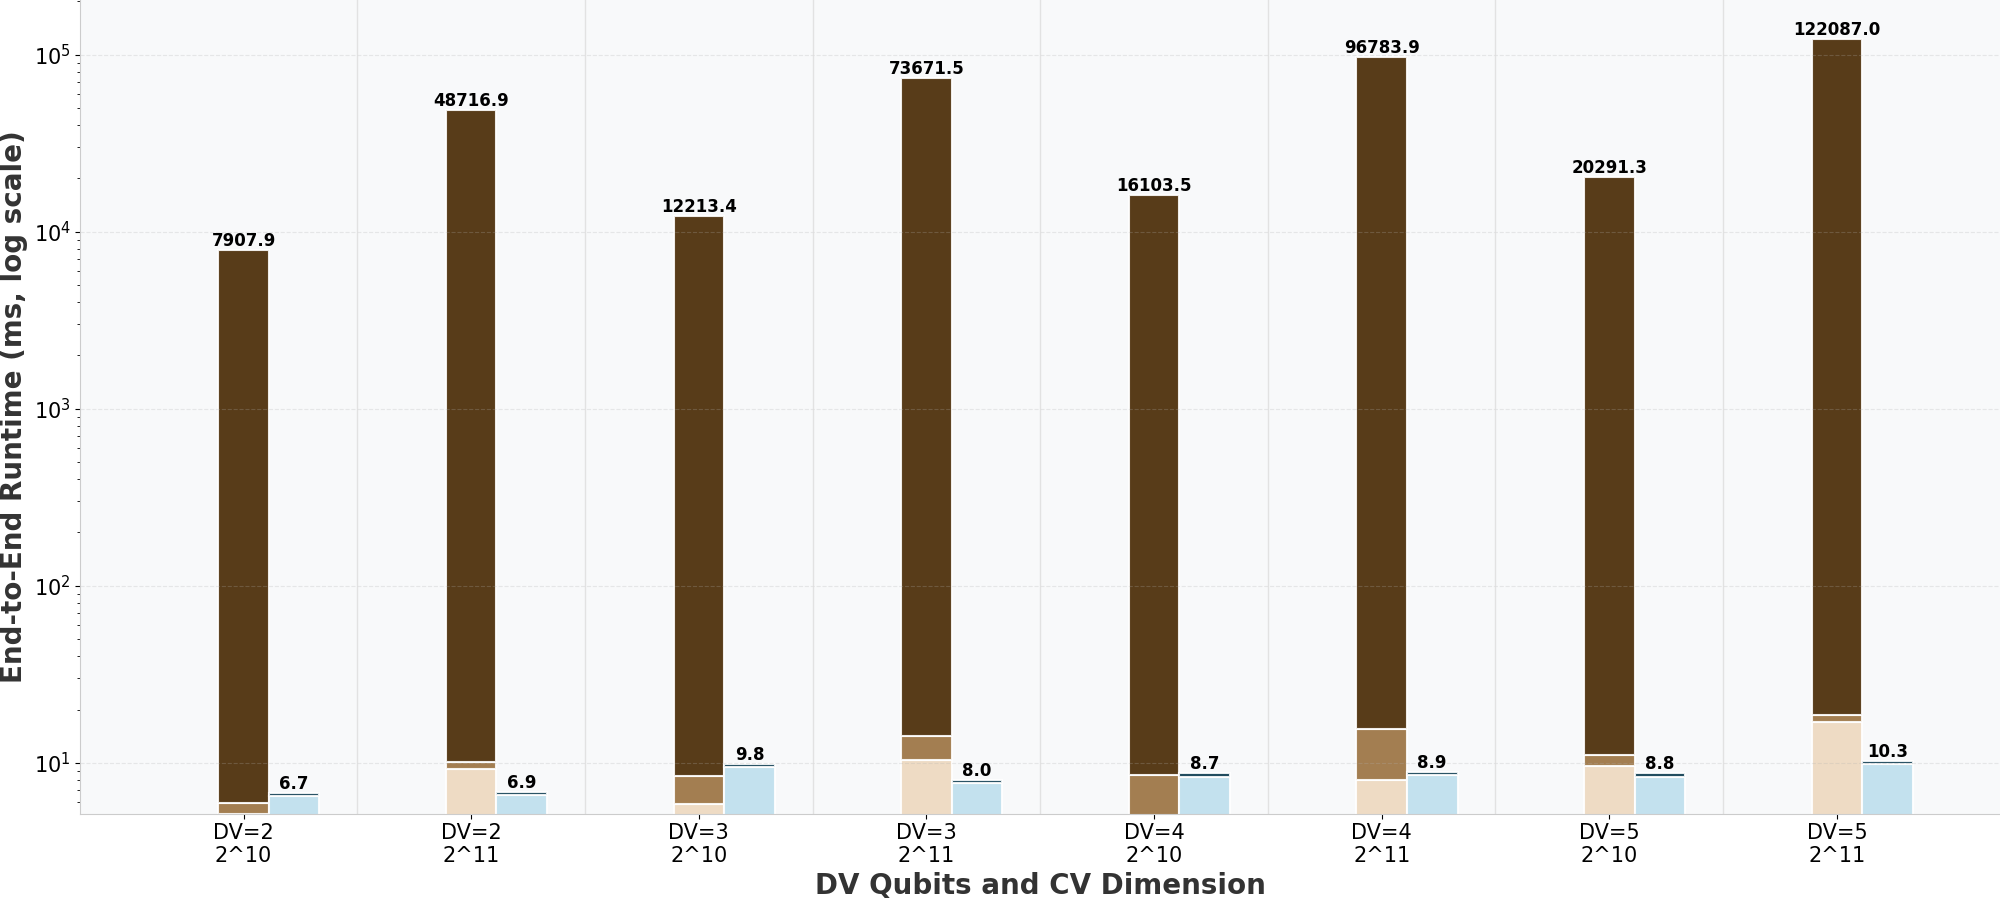

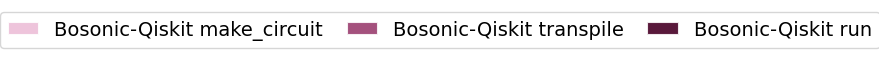

✓ Saved: images/legend_sf_Bosonic-Qiskit.pdf


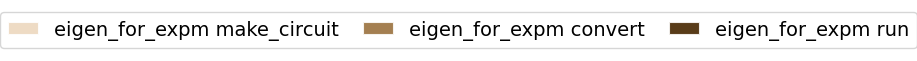

✓ Saved: images/legend_sf_eigen_for_expm.pdf


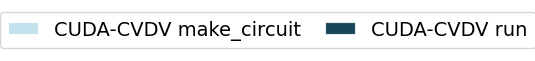

✓ Saved: images/legend_sf_CUDA-CVDV.pdf


In [6]:

# ── results_w_same_final_circuit: load ───────────────────────────────────────
SF_RESULTS_ROOT = Path('results_w_same_final_circuit')
sf_campaign = sorted(SF_RESULTS_ROOT.glob('*/runs'))[0].parent
sf_run_files = sorted(sf_campaign.glob('runs/*/same_final_circuits_runtime.json'))
print(f"✓ Found {len(sf_run_files)} files in {sf_campaign.name}")

sf_bosonic_data = {}
sf_cvdv_data    = {}
sf_qcvdv_data   = defaultdict(dict)
sf_all_pairs    = set()

for rf in sf_run_files:
    tag  = rf.parent.name
    dv_q = int(tag.split('__')[0].replace('dv', ''))
    with open(rf) as _f:
        _data = json.load(_f)
    for cv_str, cv_block in _data['results'].items():
        cv_q = int(cv_str)
        pair = (dv_q, cv_q)
        sf_all_pairs.add(pair)
        for be in cv_block['backends']:
            bk      = be['backend']
            mth     = be.get('method')
            summary = be.get('summary', {})
            def _ms(k, _s=summary):
                return float((_s.get(k) or {}).get('mean', 0.0)) * 1000.0
            if bk == 'bosonic':
                sf_bosonic_data[pair] = dict(make_circuit_mean_ms=_ms('build'),
                                             transpile_mean_ms=_ms('compile'),
                                             run_mean_ms=_ms('run'))
            elif bk == 'cvdv':
                sf_cvdv_data[pair]    = dict(make_circuit_mean_ms=_ms('build'),
                                             run_mean_ms=_ms('run'))
            elif bk == 'qcvdv':
                sf_qcvdv_data[mth or 'unknown'][pair] = dict(
                    make_circuit_mean_ms=_ms('build'),
                    convert_mean_ms=_ms('compile'),
                    run_mean_ms=_ms('run'),
                )

sf_all_pairs = sorted(sf_all_pairs)
print(f"  Pairs available: {len(sf_all_pairs)}  DV={sorted({p[0] for p in sf_all_pairs})}  CV={sorted({p[1] for p in sf_all_pairs})}")
print(f"  QCVDV methods: {list(sf_qcvdv_data.keys())}")

# Colour palette for qcvdv methods (align with original index ordering)
_all_sorted_methods = sorted(qcvdv_times.keys())
sf_method_shades = {}
for mth in sf_qcvdv_data:
    idx = _all_sorted_methods.index(mth) if mth in _all_sorted_methods else 0
    sf_method_shades[mth] = make_shades(QCVDV_METHOD_BASES[idx % len(QCVDV_METHOD_BASES)], 3)

# ── Plot (same DV/CV filter as results plots) ─────────────────────────────────
sf_fig, sf_ax  = plt.subplots(figsize=(20, 9))
sf_fig.patch.set_facecolor('white')
sf_ax.set_facecolor('#F8F9FA')

sf_bar_segments  = []
sf_x_positions   = []
sf_group_centers = []
sf_group_labels  = []
sf_group_bounds  = []
_bar_spacing = 0.8
_group_gap   = 1.2
_cur_x       = 0.0

sf_pairs_by_dv = defaultdict(list)
for p in sf_all_pairs:
    if p[0] in plot_dv_qubits and p[1] in plot_cv_qubits:
        sf_pairs_by_dv[p[0]].append(p)

for dv_q in sorted(sf_pairs_by_dv.keys()):
    for _, cv_q in sorted(sf_pairs_by_dv[dv_q], key=lambda x: x[1]):
        pair = (dv_q, cv_q)
        _grp_positions = []
        _grp_entries   = []

        bos = sf_bosonic_data.get(pair)
        if bos:
            _grp_entries.append(('Bosonic-Qiskit', [
                ('Bosonic-Qiskit make_circuit', bos['make_circuit_mean_ms'], bosonic_make_circuit_c),
                ('Bosonic-Qiskit transpile',    bos['transpile_mean_ms'],    bosonic_transpile_c),
                ('Bosonic-Qiskit run',          bos['run_mean_ms'],          bosonic_run_c),
            ]))

        for mth in sorted(sf_qcvdv_data.keys()):
            res = sf_qcvdv_data[mth].get(pair)
            if res is None:
                continue
            display_name = METHOD_DISPLAY_NAMES.get(mth, mth)
            shades = sf_method_shades[mth]
            _grp_entries.append((display_name, [
                (f'{display_name} make_circuit', res['make_circuit_mean_ms'], shades[0]),
                (f'{display_name} convert',      res['convert_mean_ms'],      shades[1]),
                (f'{display_name} run',          res['run_mean_ms'],          shades[2]),
            ]))

        cvd = sf_cvdv_data.get(pair)
        if cvd:
            _grp_entries.append(('CUDA-CVDV', [
                ('CUDA-CVDV make_circuit', cvd['make_circuit_mean_ms'], cvdv_make_circuit_c),
                ('CUDA-CVDV run',          cvd['run_mean_ms'],          cvdv_run_c),
            ]))

        if not _grp_entries:
            continue

        for lib, segs in _grp_entries:
            sf_bar_segments.append(segs)
            sf_x_positions.append(_cur_x)
            _grp_positions.append(_cur_x)
            _cur_x += _bar_spacing

        sf_group_centers.append(float(np.mean(_grp_positions)))
        sf_group_labels.append(f'DV={dv_q}\n2^{cv_q}')
        sf_group_bounds.append(_grp_positions[-1] + (_bar_spacing + _group_gap) / 2)
        _cur_x += _group_gap

# Draw bars
_sf_bars = []
for x_pos, segments in zip(sf_x_positions, sf_bar_segments):
    _bot = _tot = 0.0
    _top_bar = None
    for seg_label, seg_val, seg_color in segments:
        _top_bar = sf_ax.bar(x_pos, seg_val, width, bottom=_bot,
                             color=seg_color, alpha=0.9, edgecolor='white', linewidth=1.5)[0]
        _bot += seg_val
        _tot += seg_val
    _sf_bars.append((_top_bar, _tot))

for _bar, _tot in _sf_bars:
    if _tot > 0:
        sf_ax.text(_bar.get_x() + _bar.get_width() / 2., _tot,
                   f'{_tot:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

sf_ax.set_ylabel('End-to-End Runtime (ms, log scale)', fontsize=20, fontweight='bold', color='#333')
sf_ax.set_xlabel('DV Qubits and CV Dimension', fontsize=20, fontweight='bold', color='#333')
sf_ax.set_yscale('log')
sf_ax.set_xticks(sf_group_centers)
sf_ax.set_xticklabels(sf_group_labels, fontsize=15)
sf_ax.tick_params(axis='x', labelsize=15)
sf_ax.tick_params(axis='y', labelsize=15)
for _bnd in sf_group_bounds[:-1]:
    sf_ax.axvline(_bnd, color='#DDDDDD', linewidth=1.0, alpha=0.8)
sf_ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8, axis='y')
sf_ax.spines['top'].set_visible(False)
sf_ax.spines['right'].set_visible(False)
sf_ax.spines['left'].set_color('#CCCCCC')
sf_ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout(pad=0)
sf_pdf = images_dir / 'comparison_same_final_circuit.pdf'
sf_fig.savefig(sf_pdf, format='pdf', bbox_inches='tight', pad_inches=0, facecolor='white')
print(f"✓ Saved: {sf_pdf}")
plt.show()
plt.close(sf_fig)

# ── per-backend legend PDFs ───────────────────────────────────────────────────
sf_legend_map = {}
for segments in sf_bar_segments:
    for label, _, color in segments:
        if label not in sf_legend_map and not label.endswith(':rest'):
            sf_legend_map[label] = color

sf_ordered_backends = (
    ['Bosonic-Qiskit']
    + [METHOD_DISPLAY_NAMES.get(m, m) for m in sorted(sf_qcvdv_data.keys())]
    + ['CUDA-CVDV']
)
sf_backend_groups = {b: [] for b in sf_ordered_backends}
for label in sf_legend_map:
    if label.startswith('Bosonic-Qiskit'):
        sf_backend_groups['Bosonic-Qiskit'].append(label)
    elif label.startswith('CUDA-CVDV'):
        sf_backend_groups['CUDA-CVDV'].append(label)
    else:
        bname = label.split(' ', 1)[0]
        if bname in sf_backend_groups:
            sf_backend_groups[bname].append(label)

for backend_name in sf_ordered_backends:
    grp = sf_backend_groups[backend_name]
    if not grp:
        continue
    elems = [
        Patch(facecolor=sf_legend_map[lbl], alpha=0.9, edgecolor='white', linewidth=1.5, label=lbl)
        for lbl in grp
    ]
    n_items = len(elems)
    leg_fig, leg_ax = plt.subplots(figsize=(max(4.0, 2.5 * n_items), 0.8))
    leg_ax.axis('off')
    leg = leg_ax.legend(
        handles=elems, loc='center', ncol=n_items,
        fontsize=14, frameon=True, shadow=False, fancybox=True,
        handlelength=1.6, columnspacing=1.2,
    )
    leg.get_frame().set_edgecolor('#CCCCCC')
    leg.get_frame().set_linewidth(1.0)
    safe_name = backend_name.replace(':', '_').replace('/', '_')
    leg_pdf = images_dir / f'legend_sf_{safe_name}.pdf'
    leg_fig.canvas.draw()
    bbox = leg.get_window_extent(leg_fig.canvas.get_renderer()).transformed(leg_fig.dpi_scale_trans.inverted())
    plt.show()
    leg_fig.savefig(leg_pdf, format='pdf', bbox_inches=bbox, pad_inches=0, facecolor='white')
    print(f"✓ Saved: {leg_pdf}")
    plt.close(leg_fig)
